In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import arch
import datetime
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
import warnings
import itertools

In [53]:

def get_daily_prices(tickers, years_back=5):
    """
    Descarga la serie diaria de precios ajustados para uno o varios tickers.
    
    Args:
        tickers (str or list): Símbolo del activo o lista de símbolos (ej: 'AAPL' o ['AAPL', 'MSFT']).
        years_back (int): Años de historia desde el día de hoy.
        
    Returns:
        pd.DataFrame: DataFrame con los precios de cierre ajustados.
    """
    # Asegurar que tickers sea una lista para consistencia en yf.download
    if isinstance(tickers, str):
        tickers_list = [tickers]
    else:
        tickers_list = tickers
            
    # Calcular fechas
    end_date = datetime.datetime.now()
    start_date = end_date - datetime.timedelta(days=years_back * 365)
    
    # Descargar datos
    df = yf.download(tickers_list, start=start_date, end=end_date)['Close']
    
    # Asegurar que el resultado sea siempre un DataFrame
    if isinstance(df, pd.Series):
        df = df.to_frame(name=tickers if isinstance(tickers, str) else tickers[0])
    
    return df

def calculate_log_returns(df):
    """
    Calcula los retornos logarítmicos a partir de un DataFrame de precios.
    
    Args:
        df (pd.DataFrame): DataFrame con series de precios en las columnas.
        
    Returns:
        pd.DataFrame: DataFrame con los retornos logarítmicos, sin valores nulos.
    """
    # Cálculo: ln(Pt / Pt-1)
    log_returns = (np.log(df / df.shift(1))*100).dropna()
    
    return log_returns



def get_descriptive_stats(df):
    """
    Calcula estadísticos descriptivos y prueba de Dickey-Fuller para cada columna.
    
    Args:
        df (pd.DataFrame): DataFrame con series de retornos.
        
    Returns:
        pd.DataFrame: Resumen de estadísticos (Media, Min, Max, Std, Skew, Kurt, ADF p-value).
    """
    stats_list = []
    
    for col in df.columns:
        series = df[col].dropna()
        
        # Estadísticos básicos
        mean_val = series.mean()
        min_val = series.min()
        max_val = series.max()
        std_val = series.std()
        skew_val = series.skew()
        kurt_val = series.kurtosis() # Exceso de curtosis (Pearson - 3)
        
        # Prueba de Dickey-Fuller Aumentada (ADF)
        adf_result = adfuller(series)
        adf_pvalue = adf_result[1]
        
        stats_list.append({
            'Ticker': col,
            'Media': mean_val,
            'Mínimo': min_val,
            'Máximo': max_val,
            'Desv. Est.': std_val,
            'Asimetría': skew_val,
            'Curtosis': kurt_val,
            'ADF p-value': adf_pvalue
        })
    
    stats_df = pd.DataFrame(stats_list).set_index('Ticker')
    return stats_df

def plot_price_returns_analysis(prices, returns, ticker_name):
    """
    Genera dos gráficos para el análisis de un activo:
    1. Precios y Retornos en el tiempo.
    2. Histograma de retornos con métricas de Asimetría y Curtosis.
    
    Args:
        prices (pd.Series or pd.DataFrame): Serie de precios.
        returns (pd.Series or pd.DataFrame): Serie de retornos.
        ticker_name (str): Nombre del ticker para el título.
    """
    # Asegurar que sean Series para facilitar el manejo
    if isinstance(prices, pd.DataFrame): prices = prices.iloc[:, 0]
    if isinstance(returns, pd.DataFrame): returns = returns.iloc[:, 0]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    plt.subplots_adjust(hspace=0.4)
    
    # --- Gráfico 1: Precios y Retornos ---
    ax1.plot(prices.index, prices, color='blue', label='Precio')
    ax1.set_ylabel('Precio', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_title(f'Análisis de Precios y Retornos: {ticker_name}')
    
    # Crear un segundo eje Y para los retornos
    ax1_ret = ax1.twinx()
    ax1_ret.plot(returns.index, returns, color='orange', alpha=0.5, label='Retornos')
    ax1_ret.set_ylabel('Retornos Logarítmicos', color='orange')
    ax1_ret.tick_params(axis='y', labelcolor='orange')
    
    ax1.grid(True, alpha=0.3)
    
    # --- Gráfico 2: Histograma con Asimetría y Curtosis ---
    sns_installed = False
    try:
        import seaborn as sns
        sns.histplot(returns, kde=True, ax=ax2, color='teal', bins=50)
        sns_installed = True
    except ImportError:
        ax2.hist(returns, bins=50, color='teal', alpha=0.7)
        
    ax2.set_title(f'Distribución de Retornos: {ticker_name}')
    ax2.set_xlabel('Retorno Logarítmico')
    
    # Calcular métricas para el texto
    skew_val = returns.skew()
    kurt_val = returns.kurtosis()
    
    stats_text = f'Asimetría: {skew_val:.2f}\nCurtosis: {kurt_val:.2f}'
    ax2.text(0.95, 0.95, stats_text, transform=ax2.transAxes, 
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    
    ax2.grid(True, alpha=0.3)
    
    plt.show()

def analyze_autocorrelation(series, lags=20, ticker_name=""):
    """
    Realiza un análisis de autocorrelación incluyendo ACF, PACF y la prueba de Ljung-Box.
    
    Args:
        series (pd.Series): Serie de retornos.
        lags (int): Número de rezagos a analizar.
        ticker_name (str): Nombre del activo para los títulos.
        
    Returns:
        pd.DataFrame: Resultados de la prueba de Ljung-Box (estadístico y p-value).
    """
    import matplotlib.pyplot as plt
    
    # Eliminar NaNs si existen
    series_clean = series.dropna()
    
    # --- Gráficos ACF y PACF ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    plot_acf(series_clean, lags=lags, ax=ax1, title=f"ACF: Autocorrelación {ticker_name}")
    plot_pacf(series_clean, lags=lags, ax=ax2, title=f"PACF: Autocorrelación Parcial {ticker_name}")
    
    ax1.grid(True, alpha=0.3)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # --- Prueba de Ljung-Box ---
    # Evalúa si las autocorrelaciones de hasta el lag 'lags' son distintas de cero.
    # H0: Los datos son ruido blanco.
    lb_results = acorr_ljungbox(series_clean, lags=[lags], return_df=True)
    
    print(f"\nPrueba de Ljung-Box (lag {lags}):")
    print(lb_results)
    
    return lb_results

def find_best_arima(series, max_p=3, max_d=1, max_q=3):
    """
    Realiza una búsqueda de malla (grid search) para encontrar los mejores parámetros ARIMA (p, d, q) 
    basados en el criterio de información de Akaike (AIC).
    
    Args:
        series (pd.Series): Serie de tiempo (usualmente retornos).
        max_p (int): Máximo orden de auto-regresión.
        max_d (int): Máximo orden de diferenciación.
        max_q (int): Máximo orden de media móvil.
        
    Returns:
        tuple: (best_order, best_aic, best_model)
    """
    best_aic = float("inf")
    best_order = None
    best_mdl = None

    # Generar todas las combinaciones posibles de p, d, q
    p_range = range(max_p + 1)
    d_range = range(max_d + 1)
    q_range = range(max_q + 1)
    pdq_combinations = list(itertools.product(p_range, d_range, q_range))

    print(f"Buscando el mejor modelo ARIMA entre {len(pdq_combinations)} combinaciones...")
    
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        for order in pdq_combinations:
            try:
                tmp_mdl = ARIMA(series, order=order).fit()
                tmp_aic = tmp_mdl.aic
                if tmp_aic < best_aic:
                    best_aic = tmp_aic
                    best_order = order
                    best_mdl = tmp_mdl
            except:
                continue

    print(f"Mejor ARIMA{best_order} - AIC: {best_aic:.2f}")
    return best_order, best_aic, best_mdl

In [54]:
tickers = ['^GSPC']
prices = get_daily_prices(tickers)
prices.head()

[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2021-02-17,3931.330078
2021-02-18,3913.969971
2021-02-19,3906.709961
2021-02-22,3876.500000
2021-02-23,3881.370117


In [55]:
returns = calculate_log_returns(prices)
returns.head()

Ticker,^GSPC
Date,
2021-02-18,-0.442561
2021-02-19,-0.185662
2021-02-22,-0.776289
2021-02-23,0.125553
2021-02-24,1.128767


In [56]:
res_stats = get_descriptive_stats(returns)
res_stats

,Media,Mínimo,Máximo,Desv. Est.,Asimetría,Curtosis,ADF p-value
Ticker,,,,,,,
^GSPC,0.044119,-6.160906,9.089488,1.064777,0.014895,6.524518,0.0


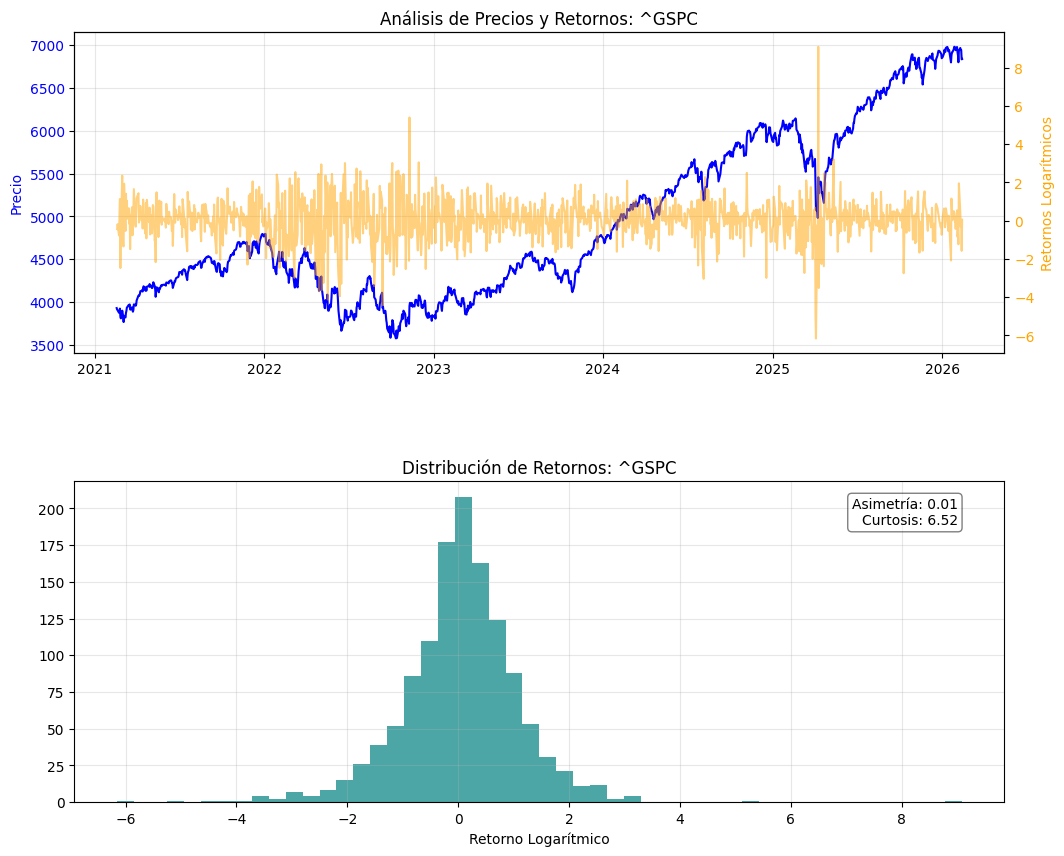

In [57]:
plot_price_returns_analysis(prices['^GSPC'], returns['^GSPC'], '^GSPC')

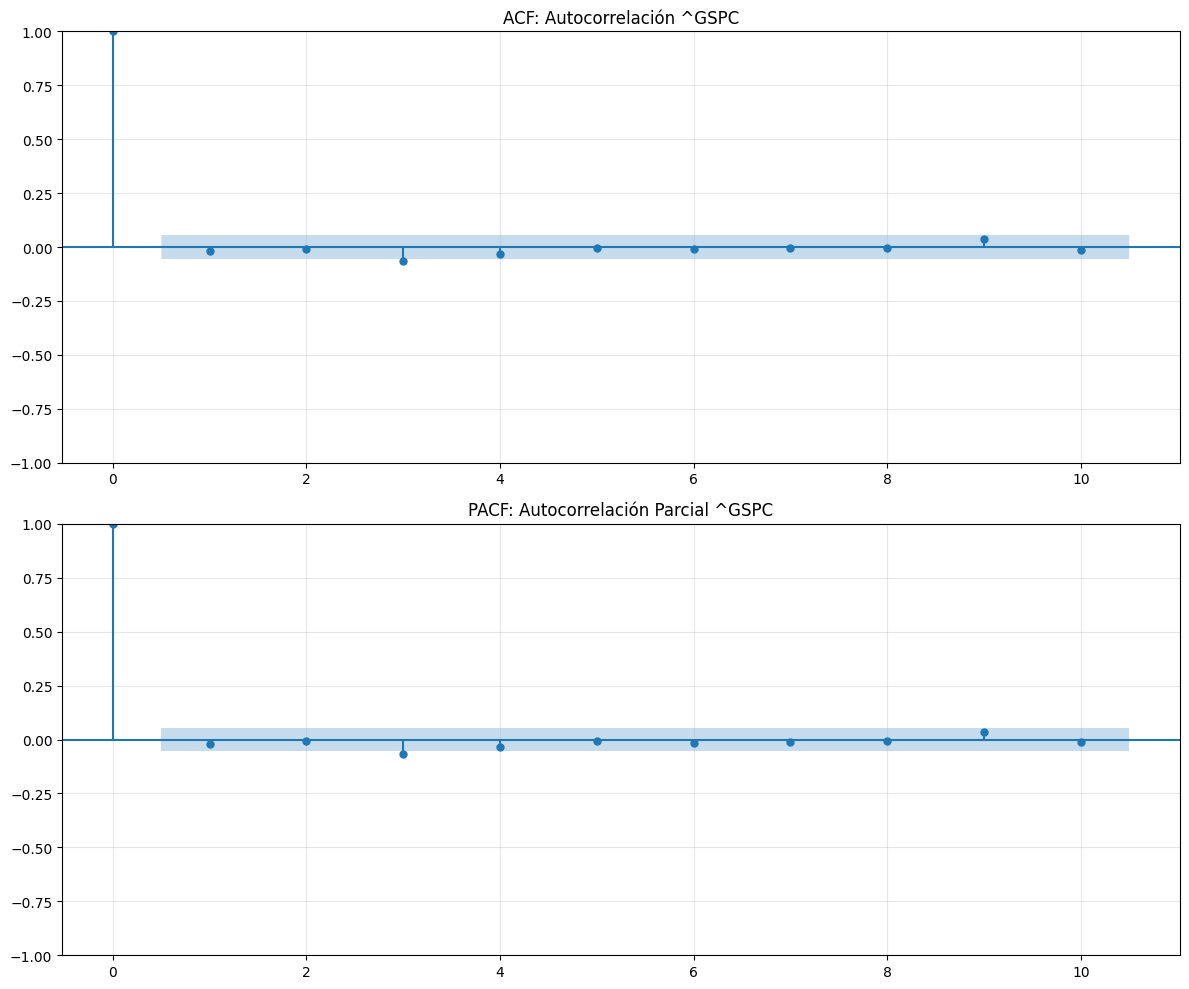


Prueba de Ljung-Box (lag 10):
     lb_stat  lb_pvalue
10  9.606761   0.475644


In [58]:
# Ejemplo de uso:
lb_res = analyze_autocorrelation(returns['^GSPC'], lags=10, ticker_name='^GSPC')

In [59]:
# Ejemplo de uso:
order, aic, model = find_best_arima(returns['^GSPC'], max_p=3, max_d=1, max_q=3)
print(model.summary())

Buscando el mejor modelo ARIMA entre 32 combinaciones...
Mejor ARIMA(0, 0, 3) - AIC: 3718.51
                               SARIMAX Results                                
Dep. Variable:                  ^GSPC   No. Observations:                 1254
Model:                 ARIMA(0, 0, 3)   Log Likelihood               -1854.253
Date:                Sun, 15 Feb 2026   AIC                           3718.506
Time:                        23:36:31   BIC                           3744.176
Sample:                             0   HQIC                          3728.155
                               - 1254                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0443      0.029      1.547      0.122      -0.012       0.100
ma.L1         -0.0251      0.018     -

In [62]:
model = arch.arch_model(returns, mean='constant', lags=1 ,vol='Garch', p=1, q=1, dist='skewt')
results = model.fit()
print(results.summary())

Iteration:      1,   Func. Count:      8,   Neg. LLF: 8225.175936505286
Iteration:      2,   Func. Count:     20,   Neg. LLF: 58958.475021813996
Iteration:      3,   Func. Count:     29,   Neg. LLF: 38016.574492683925
Iteration:      4,   Func. Count:     38,   Neg. LLF: 31536.933169509335
Iteration:      5,   Func. Count:     46,   Neg. LLF: 34132.7252040272
Iteration:      6,   Func. Count:     54,   Neg. LLF: 1679.356748297364
Iteration:      7,   Func. Count:     62,   Neg. LLF: 1841.5053647155978
Iteration:      8,   Func. Count:     71,   Neg. LLF: 1676.708741703516
Iteration:      9,   Func. Count:     79,   Neg. LLF: 1676.6585246944855
Iteration:     10,   Func. Count:     87,   Neg. LLF: 1676.5975860406625
Iteration:     11,   Func. Count:     94,   Neg. LLF: 1676.5974708742783
Iteration:     12,   Func. Count:    101,   Neg. LLF: 1676.597460664818
Iteration:     13,   Func. Count:    107,   Neg. LLF: 1676.597460664811
Optimization terminated successfully    (Exit mode 0)
    

In [65]:
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

model = MarkovRegression(returns, k_regimes=2, switching_variance=True)
# 2. Estimar el modelo
results = model.fit()
# 3. Obtener la Matriz de Transición
# Los parámetros de transición están en results.regime_transition
print("Matriz de Transición:")
print(results.regime_transition)

d:\Python\Paper_tesis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Matriz de Transición:
[[[0.99314805]
  [0.01314652]]

 [[0.00685195]
  [0.98685348]]]


In [66]:
help(MarkovRegression)

Help on class MarkovRegression in module statsmodels.tsa.regime_switching.markov_regression:

class MarkovRegression(statsmodels.tsa.regime_switching.markov_switching.MarkovSwitching)
 |  MarkovRegression(endog, k_regimes, trend='c', exog=None, order=0, exog_tvtp=None, switching_trend=True, switching_exog=True, switching_variance=False, dates=None, freq=None, missing='none')
 |
 |  First-order k-regime Markov switching regression model
 |
 |  Parameters
 |  ----------
 |  endog : array_like
 |      The endogenous variable.
 |  k_regimes : int
 |      The number of regimes.
 |  trend : {'n', 'c', 't', 'ct'}
 |      Whether or not to include a trend. To include an intercept, time trend,
 |      or both, set `trend='c'`, `trend='t'`, or `trend='ct'`. For no trend,
 |      set `trend='n'`. Default is an intercept.
 |  exog : array_like, optional
 |      Array of exogenous regressors, shaped nobs x k.
 |  order : int, optional
 |      The order of the model describes the dependence of the l